<a href="https://colab.research.google.com/github/kshamie3505-a11y/Codveda-Internship-Tasks/blob/main/Level2Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 1: Predictive Modeling
(Regression)Description: Build and evaluate a regression model to
predict a continuous variable (e.g., house prices).**

**Loading the Boston Housing dataset**

In [1]:
import pandas as pd
df = pd.read_csv('/content/HousingData.csv')
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [2]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [3]:
df.info

<bound method DataFrame.info of         CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  \
0    0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296   
1    0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242   
2    0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242   
3    0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222   
4    0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...  ...   
501  0.06263   0.0  11.93   0.0  0.573  6.593  69.1  2.4786    1  273   
502  0.04527   0.0  11.93   0.0  0.573  6.120  76.7  2.2875    1  273   
503  0.06076   0.0  11.93   0.0  0.573  6.976  91.0  2.1675    1  273   
504  0.10959   0.0  11.93   0.0  0.573  6.794  89.3  2.3889    1  273   
505  0.04741   0.0  11.93   0.0  0.573  6.030   NaN  2.5050    1  273   

     PTRATIO       B  LSTAT  MEDV  
0       15.3  396.90   4.98  24.0  
1       17.8  396.90   9.14  21.6  
2       17.8  392.83   4.03  34.7  
3       18.7  394.63   2.94  33.4  
4       18.7  396.90    NaN  36.2  
..       ...     ...    ...   ...  
501     21.0  391.99    NaN  22.4  
502     21.0  396.90   9.08  20.6  
503     21.0  396.90   5.64  23.9  
504     21.0  393.45   6.48  22.0  
505     21.0  396.90   7.88  11.9  

[506 rows x 14 columns]>

In [4]:
df.shape

(506, 14)

**Checking for missing values in the dataset**

In [5]:
df.isnull()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,False,False,False,False,False,False,False,False,False,False,False,False,True,False
502,False,False,False,False,False,False,False,False,False,False,False,False,False,False
503,False,False,False,False,False,False,False,False,False,False,False,False,False,False
504,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
df.isnull().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


**Imputing missing values with the mean: replacing missing numerical values with the mean of their respective columns.**

In [7]:
df_imputed = df.copy()

# List of columns with missing values identified earlier
columns_with_nan = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'AGE', 'LSTAT']

for col in columns_with_nan:
    if df_imputed[col].dtype in ['int64', 'float64']:
        df_imputed[col].fillna(df_imputed[col].mean(), inplace=True)

print("Missing values after imputation:")
display(df_imputed.isnull().sum())
display(df_imputed.head())

Missing values after imputation:


/tmp/ipykernel_716/1351828443.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed[col].fillna(df_imputed[col].mean(), inplace=True)


,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.980000,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.140000,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.030000,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.940000,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,12.715432,36.2


**Outlier Detection and Removal using IQR Method.**


In [8]:
import numpy as np

df_no_outliers = df_imputed.copy()

numerical_cols = df_imputed.select_dtypes(include=np.number).columns

print(f"Original shape of df_imputed: {df_imputed.shape}")

for col in numerical_cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out outliers
    df_no_outliers = df_no_outliers[(df_no_outliers[col] >= lower_bound) & (df_no_outliers[col] <= upper_bound)]

print(f"Shape of DataFrame after outlier removal: {df_no_outliers.shape}")
display(df_no_outliers.head())

Original shape of df_imputed: (506, 14)
Shape of DataFrame after outlier removal: (206, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
7,0.14455,12.5,7.87,0.0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
10,0.22489,12.5,7.87,0.0,0.524,6.377,94.3,6.3467,5,311,15.2,392.52,20.45,15.0


**Applying StandardScaler to df_no_outliers before building the model**.
This standardizes numerical features and it's important for many machine learning algorithms like linear regression which are sensitive to feature scales.

In [9]:
from sklearn.preprocessing import StandardScaler

# Create a copy of df_no_outliers to store the scaled data, copying maintains the original data
df_scaled = df_no_outliers.copy()

# Identify numerical columns to scale
numerical_features = df_scaled.select_dtypes(include=np.number).columns.tolist()
if 'MEDV' in numerical_features:
    numerical_features.remove('MEDV') # excluding MEDV which is the target variable.

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the selected numerical features
df_scaled[numerical_features] = scaler.fit_transform(df_scaled[numerical_features])

print("DataFrame after applying StandardScaler (first 5 rows):")
display(df_scaled.head())

print("Mean of scaled features (should be close to 0):")
display(df_scaled[numerical_features].mean())

print("Standard deviation of scaled features (should be close to 1):")
display(df_scaled[numerical_features].std())

DataFrame after applying StandardScaler (first 5 rows):


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,-0.508533,0.966048,-1.235747,0.0,0.664319,0.943274,0.202139,-0.180728,-2.131374,-0.228589,-2.084531,0.795970,-1.395706,24.0
1,-0.475533,-0.567705,-0.318922,0.0,-0.523732,0.535039,0.730959,0.318931,-1.522410,-1.047533,-0.561789,0.795970,-0.370655,21.6
5,-0.471540,-0.567705,-1.260787,0.0,-0.713132,0.558897,-0.048761,0.942779,-0.913446,-1.350846,-0.013601,0.392793,-1.339032,28.7
7,-0.291215,0.497401,-0.164833,0.0,0.423265,-0.125029,1.394879,0.879146,0.304482,-0.001104,-2.145441,0.795970,2.095872,27.1
10,-0.164909,0.497401,-0.164833,0.0,0.423265,0.418401,1.325399,1.104850,0.304482,-0.001104,-2.145441,0.160748,2.416200,15.0


Mean of scaled features (should be close to 0):


,0
CRIM,8.623091e-18
ZN,4.311546e-17
INDUS,1.293464e-16
CHAS,0.000000e+00
NOX,5.001393e-16
RM,-2.423089e-15
AGE,-1.207233e-16
DIS,-2.910293e-17
RAD,8.623091e-18
TAX,-8.191937e-17


Standard deviation of scaled features (should be close to 1):


,0
CRIM,1.002436
ZN,1.002436
INDUS,1.002436
CHAS,0.000000
NOX,1.002436
RM,1.002436
AGE,1.002436
DIS,1.002436
RAD,1.002436
TAX,1.002436


**Building a Linear Regression model by splitting the data into training and testing sets,and evaluate its performance.**

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Separate features (X) and target (y)
X = df_scaled.drop('MEDV', axis=1)
y = df_scaled['MEDV']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (164, 13)
X_test shape: (42, 13)
y_train shape: (164,)
y_test shape: (42,)


Mean Squared Error (MSE): 5.09
R-squared (R2): 0.75


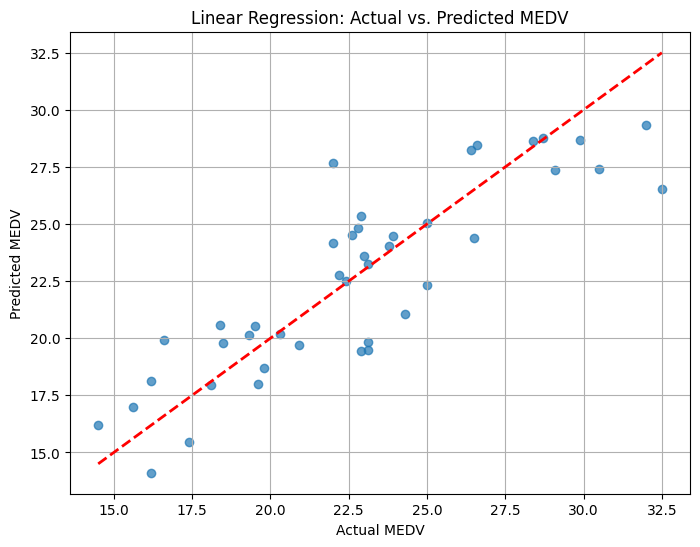

In [11]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")


import matplotlib.pyplot as plt

# Plotting y_test vs y_pred for Linear Regression
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line for perfect prediction
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Linear Regression: Actual vs. Predicted MEDV")
plt.grid(True)
plt.show()

**Experimenting with Decision Tree and Random Forest and comparing performance.**


--- Decision Tree Regressor ---
Decision Tree Mean Squared Error (MSE): 12.99
Decision Tree R-squared (R2): 0.35

--- Random Forest Regressor ---
Random Forest Mean Squared Error (MSE): 5.67
Random Forest R-squared (R2): 0.72

--- Performance Comparison ---
Linear Regression R-squared (R2): 0.75
Decision Tree R-squared (R2): 0.35
Random Forest R-squared (R2): 0.72


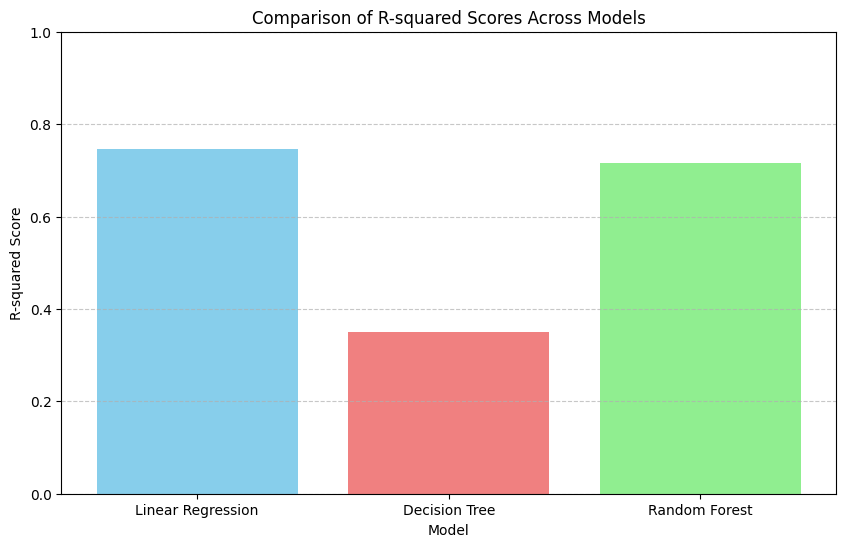

In [12]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

print("\n--- Decision Tree Regressor ---")
# Initialize and train the Decision Tree Regressor model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions on the test set
dt_y_pred = dt_model.predict(X_test)

# Evaluate the Decision Tree model
dt_mse = mean_squared_error(y_test, dt_y_pred)
dt_r2 = r2_score(y_test, dt_y_pred)

print(f"Decision Tree Mean Squared Error (MSE): {dt_mse:.2f}")
print(f"Decision Tree R-squared (R2): {dt_r2:.2f}")

print("\n--- Random Forest Regressor ---")
# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
rf_y_pred = rf_model.predict(X_test)

# Evaluate the Random Forest model
rf_mse = mean_squared_error(y_test, rf_y_pred)
rf_r2 = r2_score(y_test, rf_y_pred)

print(f"Random Forest Mean Squared Error (MSE): {rf_mse:.2f}")
print(f"Random Forest R-squared (R2): {rf_r2:.2f}")

# Compare with Linear Regression results
print("\n--- Performance Comparison ---")
print(f"Linear Regression R-squared (R2): {r2:.2f}")
print(f"Decision Tree R-squared (R2): {dt_r2:.2f}")
print(f"Random Forest R-squared (R2): {rf_r2:.2f}")

# Plotting R-squared comparison
models = ['Linear Regression', 'Decision Tree', 'Random Forest']
r2_scores = [r2, dt_r2, rf_r2]

plt.figure(figsize=(10, 6))
plt.bar(models, r2_scores, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.ylim(0, 1) # R-squared typically ranges from 0 to 1
plt.xlabel("Model")
plt.ylabel("R-squared Score")
plt.title("Comparison of R-squared Scores Across Models")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Summary of the tasks:**

**Data Loading & Initial Inspection:**
Data Source : https://www.kaggle.com/datasets/altavish/boston-housing-dataset

I loaded the HousingData.csv into a Pandas DataFrame, examined its columns, shape, and information.
**Missing Value Handling:**
I identified columns with missing values and chose to impute them using the mean of their respective columns, resulting in df_imputed.
**Outlier Detection & Removal:**
I applied the Interquartile Range (IQR) method to detect and remove outliers from df_imputed, creating df_no_outliers. This significantly reduced the dataset size, retaining more robust data points.
**Feature Scaling:**
I applied StandardScaler to the numerical features of df_no_outliers (excluding the target variable MEDV) to standardize them, creating df_scaled. This step is crucial for linear models to ensure fair contribution of features and improved training stability.
**Model Building & Evaluation:**
I built and evaluated three regression models:
Linear Regression: Achieved an R-squared of 0.75 and an MSE of 5.09. I visualized its performance with a scatter plot of actual vs. predicted values and analyzed the coefficients to understand feature importance.
**Decision Tree Regressor:**
Showed an R-squared of 0.35 and an MSE of 12.99, indicating the lowest performance among the three.
**Random Forest Regressor:**
Achieved an R-squared of 0.72 and an MSE of 5.67, performing very closely to the Linear Regression model.
**Performance Comparison:**
A bar chart visually compared the R-squared scores, clearly illustrating Linear Regression as the top performer, followed closely by Random Forest.
Overall, the Linear Regression model, applied to the carefully preprocessed data, proved to be the most effective in predicting Boston home prices with an R-squared of 0.75, meaning it explains 75% of the variance in home values.